In [2]:
import pandas as pd

# Creacion de la base de datos

In [21]:
comprobantes = pd.read_excel('Comprobantes detallados.xlsx', header=7)
comprobantes.head(10)

,Secuencia,Fecha elaboración,Código contable,Cuenta contable,Identificación,Sucursal,Nombre tercero,Descripción,Detalle,Centro de costo,Débito,Crédito
0,Comprobante: A-376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,791634.31,791634.31
1,1,07/02/2026,14350101.0,Mercancías no fabricadas,901678785.0,0.0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU ROJO THHN-2 600V ROLLO X 100,Prod: NX10011765 Cant: 1.00,NaN,0.00,199730.25
2,2,07/02/2026,61350520.0,Ajuste de Inventarió,901678785.0,0.0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,199730.25,0.00
3,3,07/02/2026,14350101.0,Mercancías no fabricadas,901678785.0,0.0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU ROJO THHN-2 600V X MT,Prod: NX10024729 Cant: 100.00,NaN,200670.00,0.00
4,4,07/02/2026,61350520.0,Ajuste de Inventarió,901678785.0,0.0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,0.00,200670.00
5,5,07/02/2026,14350101.0,Mercancías no fabricadas,901678785.0,0.0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU VERDE THHN-2 600V ROLLO X 100,Prod: NX10011767 Cant: 1.00,NaN,0.00,199072.06
6,6,07/02/2026,61350520.0,Ajuste de Inventarió,901678785.0,0.0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,199072.06,0.00
7,7,07/02/2026,14350101.0,Mercancías no fabricadas,901678785.0,0.0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU VERDE THHN-2 600V X MT,Prod: NX10024731 Cant: 100.00,NaN,192162.00,0.00
8,8,07/02/2026,61350520.0,Ajuste de Inventarió,901678785.0,0.0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,0.00,192162.00
9,Comprobante: A-377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1396.07,1396.07


In [22]:
# Extraer código de comprobante de las filas encabezado y propagarlo
comprobantes['Comprobante'] = comprobantes['Secuencia'].where(
    comprobantes['Secuencia'].astype(str).str.startswith('Comprobante:')
).ffill()

# Extraer solo el código (ej: "A-376" de "Comprobante: A-376")
comprobantes['Comprobante'] = comprobantes['Comprobante'].str.replace('Comprobante: ', '', regex=False)

# Eliminar las filas encabezado de comprobante (quedan solo las secuencias)
comprobantes = comprobantes[~comprobantes['Secuencia'].astype(str).str.startswith('Comprobante:')].reset_index(drop=True)

# Convertir columnas a entero (Int64 soporta NaN)
comprobantes['Código contable'] = comprobantes['Código contable'].astype('Int64')
comprobantes['Identificación'] = comprobantes['Identificación'].astype('Int64')
comprobantes['Sucursal'] = comprobantes['Sucursal'].astype('Int64')

# Crear columna Movimiento: crédito cuando débito es 0, -débito cuando crédito es 0
comprobantes['Movimiento'] = comprobantes.apply(
    lambda r: r['Crédito'] if r['Débito'] == 0 else -r['Débito'], axis=1
)

# Mover Comprobante al inicio del dataframe
cols = ['Comprobante'] + [c for c in comprobantes.columns if c != 'Comprobante']
comprobantes = comprobantes[cols]

comprobantes.head(20)

,Comprobante,Secuencia,Fecha elaboración,Código contable,Cuenta contable,Identificación,Sucursal,Nombre tercero,Descripción,Detalle,Centro de costo,Débito,Crédito,Movimiento
0,A-376,1,07/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU ROJO THHN-2 600V ROLLO X 100,Prod: NX10011765 Cant: 1.00,NaN,0.00,199730.25,199730.25
1,A-376,2,07/02/2026,61350520,Ajuste de Inventarió,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,199730.25,0.00,-199730.25
2,A-376,3,07/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU ROJO THHN-2 600V X MT,Prod: NX10024729 Cant: 100.00,NaN,200670.00,0.00,-200670.00
3,A-376,4,07/02/2026,61350520,Ajuste de Inventarió,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,0.00,200670.00,200670.00
4,A-376,5,07/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU VERDE THHN-2 600V ROLLO X 100,Prod: NX10011767 Cant: 1.00,NaN,0.00,199072.06,199072.06
5,A-376,6,07/02/2026,61350520,Ajuste de Inventarió,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,199072.06,0.00,-199072.06
6,A-376,7,07/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU VERDE THHN-2 600V X MT,Prod: NX10024731 Cant: 100.00,NaN,192162.00,0.00,-192162.00
7,A-376,8,07/02/2026,61350520,Ajuste de Inventarió,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,0.00,192162.00,192162.00
8,A-377,1,09/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,CINTA ALISLANTE NEGRA 15 MTS GRANDE UL FMX VL ...,Prod: KL-1227 Cant: 0.00,NaN,0.00,1396.07,1396.07
9,A-377,2,09/02/2026,61350515,"Retiro de inventario para activos fijos, consu...",901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,"Retiro de inventario para activos fijos, consu...",NaN,NaN,1396.07,0.00,-1396.07


In [24]:
productos = pd.read_excel('Lista de productos.xlsx')
productos.head(10)

,Código producto,Nombre producto,MARCA DETALLADA,MARCA RESUMIDA,LINEA NEGOCIO
0,000001EM,CAJA MECANISMO 32MM ECO. EM,EM,SECUNDARIA,OTROS
1,077DEX004,CANALETA RANURADA GRIS 40*40 2M E,OTROS,SECUNDARIA,OTROS
2,10100B,BOMBILLO LED GU10 5W 6500K WELLMAX,WELLMAX,SECUNDARIA,ILUMINACION
3,10100C,BOMBILLO LED GU10 5W 3500K CEB,CEB,SECUNDARIA,ILUMINACION
4,10101B,BOMBILLO LED GU10 EDICION 12 6500K WELLMAX,WELLMAX,SECUNDARIA,ILUMINACION
5,10103B,BOMBILLO LED 5W 6500K WELLMAX,WELLMAX,SECUNDARIA,ILUMINACION
6,10105B,BOMBILLO LED 12W 6500K WELLMAX,WELLMAX,SECUNDARIA,ILUMINACION
7,10106B,BOMBILLO LED 15W 6500K WELLMAX,WELLMAX,SECUNDARIA,ILUMINACION
8,10112B,PANEL LED REDONDO INC 3W 6500K WELLMAX,WELLMAX,SECUNDARIA,ILUMINACION
9,10136,CHASIS OJO DE BUEY CEB,CEB,SECUNDARIA,ILUMINACION


In [31]:
# Extraer código de producto desde Detalle (ej: "Prod: NX10011765 Cant: 1.00")
comprobantes['Código producto'] = comprobantes['Detalle'].str.extract(r'Prod:\s*(\S+)')

# Merge con productos para traer info del producto
comprobantes = comprobantes.merge(productos[['Código producto', 'MARCA RESUMIDA', 'LINEA NEGOCIO']], on='Código producto', how='left')

comprobantes.head(20)

,Comprobante,Secuencia,Fecha elaboración,Código contable,Cuenta contable,Identificación,Sucursal,Nombre tercero,Descripción,Detalle,Centro de costo,Débito,Crédito,Movimiento,Código producto,MARCA RESUMIDA,LINEA NEGOCIO
0,A-376,1,07/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU ROJO THHN-2 600V ROLLO X 100,Prod: NX10011765 Cant: 1.00,NaN,0.00,199730.25,199730.25,NX10011765,PRIMARIA,CABLEADO
1,A-376,2,07/02/2026,61350520,Ajuste de Inventarió,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,199730.25,0.00,-199730.25,NaN,NaN,NaN
2,A-376,3,07/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU ROJO THHN-2 600V X MT,Prod: NX10024729 Cant: 100.00,NaN,200670.00,0.00,-200670.00,NX10024729,PRIMARIA,CABLEADO
3,A-376,4,07/02/2026,61350520,Ajuste de Inventarió,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,0.00,200670.00,200670.00,NaN,NaN,NaN
4,A-376,5,07/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU VERDE THHN-2 600V ROLLO X 100,Prod: NX10011767 Cant: 1.00,NaN,0.00,199072.06,199072.06,NX10011767,PRIMARIA,CABLEADO
5,A-376,6,07/02/2026,61350520,Ajuste de Inventarió,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,199072.06,0.00,-199072.06,NaN,NaN,NaN
6,A-376,7,07/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU VERDE THHN-2 600V X MT,Prod: NX10024731 Cant: 100.00,NaN,192162.00,0.00,-192162.00,NX10024731,PRIMARIA,CABLEADO
7,A-376,8,07/02/2026,61350520,Ajuste de Inventarió,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,0.00,192162.00,192162.00,NaN,NaN,NaN
8,A-377,1,09/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,CINTA ALISLANTE NEGRA 15 MTS GRANDE UL FMX VL ...,Prod: KL-1227 Cant: 0.00,NaN,0.00,1396.07,1396.07,KL-1227,SECUNDARIA,ILUMINACION
9,A-377,2,09/02/2026,61350515,"Retiro de inventario para activos fijos, consu...",901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,"Retiro de inventario para activos fijos, consu...",NaN,NaN,1396.07,0.00,-1396.07,NaN,NaN,NaN


In [39]:
productos.head()

,Código producto,Nombre producto,MARCA DETALLADA,MARCA RESUMIDA,LINEA NEGOCIO
0,000001EM,CAJA MECANISMO 32MM ECO. EM,EM,SECUNDARIA,OTROS
1,077DEX004,CANALETA RANURADA GRIS 40*40 2M E,OTROS,SECUNDARIA,OTROS
2,10100B,BOMBILLO LED GU10 5W 6500K WELLMAX,WELLMAX,SECUNDARIA,ILUMINACION
3,10100C,BOMBILLO LED GU10 5W 3500K CEB,CEB,SECUNDARIA,ILUMINACION
4,10101B,BOMBILLO LED GU10 EDICION 12 6500K WELLMAX,WELLMAX,SECUNDARIA,ILUMINACION


In [32]:
# guardar productos en un archivo csv
productos.to_csv('productos.csv', index=False)

In [40]:
# Verificar ambigüedad: ¿hay productos con mismo nombre base pero diferente marca?
productos['nombre_base'] = productos.apply(
    lambda r: r['Nombre producto'].replace('"', '').rstrip()
        .removesuffix(str(r['MARCA DETALLADA'])).rstrip()
    if pd.notna(r['MARCA DETALLADA']) else r['Nombre producto'].replace('"', '').rstrip(),
    axis=1
)

# Buscar nombres base duplicados con diferentes marcas
duplicados = productos.groupby('nombre_base').filter(lambda g: g['MARCA DETALLADA'].nunique() > 1)
duplicados = duplicados.sort_values('nombre_base')[['nombre_base', 'Código producto', 'Nombre producto', 'MARCA DETALLADA']]
print(f"Productos con mismo nombre base y diferente marca: {duplicados['nombre_base'].nunique()}")
duplicados

Productos con mismo nombre base y diferente marca: 21


,nombre_base,Código producto,Nombre producto,MARCA DETALLADA
25,PANEL LED CUADRADO INC 12W 6500K,20108,PANEL LED CUADRADO INC 12W 6500K CEB,CEB
1733,PANEL LED CUADRADO INC 12W 6500K,10120B,PANEL LED CUADRADO INC 12W 6500K WELLMAX,WELLMAX
1751,PANEL LED CUADRADO INC 18W 6500K,20109,PANEL LED CUADRADO INC 18W 6500K CEB,CEB
1734,PANEL LED CUADRADO INC 18W 6500K,10121B,PANEL LED CUADRADO INC 18W 6500K WELLMAX,WELLMAX
1752,PANEL LED CUADRADO INC 24W 6500K,20110,PANEL LED CUADRADO INC 24W 6500K CEB,CEB
1735,PANEL LED CUADRADO INC 24W 6500K,10122B,PANEL LED CUADRADO INC 24W 6500K WELLMAX,WELLMAX
1749,PANEL LED CUADRADO INC 6W 6500K,20106,PANEL LED CUADRADO INC 6W 6500K CEB,CEB
1731,PANEL LED CUADRADO INC 6W 6500K,10118B,PANEL LED CUADRADO INC 6W 6500K WELLMAX,WELLMAX
1750,PANEL LED CUADRADO INC 9W 6500K,20107,PANEL LED CUADRADO INC 9W 6500K CEB,CEB
1732,PANEL LED CUADRADO INC 9W 6500K,10119B,PANEL LED CUADRADO INC 9W 6500K WELLMAX,WELLMAX


In [43]:
import re

# Filas con producto en Detalle pero sin Código producto
sin_match = (
    comprobantes['Código producto'].isna() &
    comprobantes['Detalle'].str.contains(r'Prod(?:ucto)?:', na=False)
)
print(f"Sin match inicial: {sin_match.sum()}")

# --- Paso 1: Match exacto por nombre ---
lookup_exacto = productos.drop_duplicates('Nombre producto').set_index('Nombre producto')
desc_exacta = comprobantes.loc[sin_match, 'Descripción']
matched_exacto = desc_exacta.map(lookup_exacto['Código producto'])

for col in ['Código producto', 'MARCA RESUMIDA', 'LINEA NEGOCIO']:
    idx = matched_exacto.index[matched_exacto.notna()]
    comprobantes.loc[idx, col] = desc_exacta[matched_exacto.notna()].map(lookup_exacto[col]).values

sin_match = comprobantes['Código producto'].isna() & comprobantes['Detalle'].str.contains(r'Prod(?:ucto)?:', na=False)
print(f"Sin match después de exacto: {sin_match.sum()}")

# --- Paso 2: Match normalizado (quitar marca de ambos lados) ---
marcas_conocidas = set(productos['MARCA DETALLADA'].dropna().unique())

def normalizar_desc(s):
    s = str(s).replace('"', '').replace('\u00ba', '').strip()
    # Quitar sufijos M. GEN, M.GEN, M.GENERICA, M.GENE
    s = re.sub(r'\s+M\.?\s*GEN(?:E(?:RICA)?)?$', '', s, flags=re.IGNORECASE)
    # Quitar "M. MARCA" o "M MARCA" solo para marcas conocidas
    upper = s.upper()
    for marca in sorted(marcas_conocidas, key=len, reverse=True):
        mu = marca.upper()
        for prefijo in [f' M. {mu}', f' M.{mu}', f' M {mu}', f' {mu}']:
            if upper.endswith(prefijo):
                s = s[:len(s) - len(prefijo)]
                return s.rstrip('. ')
    return s.rstrip('. ')

lookup_base = productos.drop_duplicates('nombre_base').set_index('nombre_base')
desc_norm = comprobantes.loc[sin_match, 'Descripción'].apply(normalizar_desc)
matched_norm = desc_norm.map(lookup_base['Código producto'])

for col in ['Código producto', 'MARCA RESUMIDA', 'LINEA NEGOCIO']:
    idx = matched_norm.index[matched_norm.notna()]
    comprobantes.loc[idx, col] = desc_norm[matched_norm.notna()].map(lookup_base[col]).values

sin_match = comprobantes['Código producto'].isna() & comprobantes['Detalle'].str.contains(r'Prod(?:ucto)?:', na=False)
print(f"Sin match después de normalizado: {sin_match.sum()}")

# --- Paso 3: Match por prefijo para servicios ---
servicios = sin_match & comprobantes['Descripción'].str.startswith('Servicio', na=False)
if servicios.any():
    for idx in comprobantes.loc[servicios].index:
        desc = comprobantes.loc[idx, 'Descripción']
        for base, row in lookup_base.iterrows():
            if desc.startswith(base):
                comprobantes.loc[idx, 'Código producto'] = row['Código producto']
                comprobantes.loc[idx, 'MARCA RESUMIDA'] = row['MARCA RESUMIDA']
                comprobantes.loc[idx, 'LINEA NEGOCIO'] = row['LINEA NEGOCIO']
                break

sin_match_final = comprobantes['Código producto'].isna() & comprobantes['Detalle'].str.contains(r'Prod(?:ucto)?:', na=False)
print(f"\nSin match final: {sin_match_final.sum()}")

if sin_match_final.any():
    restantes = sorted(comprobantes.loc[sin_match_final, 'Descripción'].unique())
    print(f"\nDescripciones aún sin match ({len(restantes)}):")
    for d in restantes:
        print(f"  - {d}")

Sin match inicial: 85
Sin match después de exacto: 85
Sin match después de normalizado: 46

Sin match final: 46

Descripciones aún sin match (14):
  - A. 12AWG CU AMARILLO THHN-2 600V ROLLO X 100 M. GEN
  - A.10AWG CU ROJO THHN/THWN-2 600V X MTR CONDUMEX
  - BOMBILLO LED 40W TFORCE E27 M PHILLIPS
  - C. 10AWG CU BLANCO THHN-2 600V X MT.M. GEN
  - C. 10AWG CU ROJO THHN-2 600V X MT. M. GEN
  - C. 8AWG CU AZUL THHN/THWN-2 600V 90C X METRO M. CONDUMEX
  - C. TRENZADO 3*12AWG CU AZ/BL/VE 1000 THHN-2 X MT M.GEN
  - CINTA LED RGB + FUENTE 5 MTRS M.GEN
  - INT SENCILLO GALICA 2 M. LEGRAND
  - INTERRUPTOR DOBLE GALICA 2 M. LEGRAND
  - LED REFLECTOR JETA 50W DL ST SYLVANIA
  - PANEL LED 18W 8 6500K RED. INC. MERCURY
  - TAPA DEXSON SENSILLA
  - TOMA DUPLEX GFCI CON P/T (2P+T) GALICA 2 LEGRAND


In [46]:
# Asignaciones manuales verificadas para casos que la normalización no resuelve
asignaciones_manuales = {
    'C. 10AWG CU BLANCO THHN-2 600V X MT.M. GEN': 'NX10024651',
    'C. 10AWG CU ROJO THHN-2 600V X MT. M. GEN': 'NX10024640',
    'A. 12AWG CU AMARILLO THHN-2 600V ROLLO X 100 M. GEN': '80007095',
    'PANEL LED 18W 8 6500K RED. INC. MERCURY': 'IPL06',
}

productos_idx = productos.set_index('Código producto')

for desc, codigo in asignaciones_manuales.items():
    mask = (comprobantes['Descripción'] == desc) & comprobantes['Código producto'].isna()
    if mask.any() and codigo in productos_idx.index:
        comprobantes.loc[mask, 'Código producto'] = codigo
        comprobantes.loc[mask, 'MARCA RESUMIDA'] = productos_idx.loc[codigo, 'MARCA RESUMIDA']
        comprobantes.loc[mask, 'LINEA NEGOCIO'] = productos_idx.loc[codigo, 'LINEA NEGOCIO']
        print(f"  {desc} \u2192 {codigo} ({mask.sum()} filas)")

# Asignar código especial a los que quedan sin match
sin_match = (
    comprobantes['Código producto'].isna() &
    comprobantes['Detalle'].str.contains(r'Prod(?:ucto)?:', na=False)
)
comprobantes.loc[sin_match, 'Código producto'] = 'DESCONOCIDO'
print(f"\nAsignados como DESCONOCIDO: {sin_match.sum()}")


Asignados como DESCONOCIDO: 25


In [47]:
# guardar comprobantes en un archivo csv
comprobantes.to_csv('comprobantes.csv', index=False)

In [48]:
comprobantes.head()

,Comprobante,Secuencia,Fecha elaboración,Código contable,Cuenta contable,Identificación,Sucursal,Nombre tercero,Descripción,Detalle,Centro de costo,Débito,Crédito,Movimiento,Código producto,MARCA RESUMIDA,LINEA NEGOCIO
0,A-376,1,07/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU ROJO THHN-2 600V ROLLO X 100,Prod: NX10011765 Cant: 1.00,NaN,0.00,199730.25,199730.25,NX10011765,PRIMARIA,CABLEADO
1,A-376,2,07/02/2026,61350520,Ajuste de Inventarió,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,199730.25,0.00,-199730.25,NaN,NaN,NaN
2,A-376,3,07/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU ROJO THHN-2 600V X MT,Prod: NX10024729 Cant: 100.00,NaN,200670.00,0.00,-200670.00,NX10024729,PRIMARIA,CABLEADO
3,A-376,4,07/02/2026,61350520,Ajuste de Inventarió,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,Ajuste de Inventarió,NaN,NaN,0.00,200670.00,200670.00,NaN,NaN,NaN
4,A-376,5,07/02/2026,14350101,Mercancías no fabricadas,901678785,0,PROVEEDORA ELECTRICA NACIONAL SAS,C. 12AWG CU VERDE THHN-2 600V ROLLO X 100,Prod: NX10011767 Cant: 1.00,NaN,0.00,199072.06,199072.06,NX10011767,PRIMARIA,CABLEADO


# Procesamiento de datos

In [49]:
# Total de ventas por producto
# Filtrar facturas de venta (FV) con cuenta de ingresos (41350101)
ventas = comprobantes[
    (comprobantes['Comprobante'].str.startswith('FV')) &
    (comprobantes['Código contable'] == 41350101)
].copy()

# Extraer cantidad desde Detalle
ventas['Cantidad'] = ventas['Detalle'].str.extract(r'Cant:\s*([\d.]+)').astype(float)

# Agrupar por producto usando las columnas ya enriquecidas en comprobantes
ventas_por_producto = ventas.groupby('Código producto').agg(
    Descripción=('Descripción', 'first'),
    Marca=('MARCA RESUMIDA', 'first'),
    Línea=('LINEA NEGOCIO', 'first'),
    Cantidad_total=('Cantidad', 'sum'),
    Venta_total=('Crédito', 'sum')
).sort_values('Venta_total', ascending=False).reset_index()

print(f"Productos vendidos: {len(ventas_por_producto)}")
print(f"Venta total: ${ventas_por_producto['Venta_total'].sum():,.0f}")
ventas_por_producto

Productos vendidos: 142
Venta total: $12,307,679


,Código producto,Descripción,Marca,Línea,Cantidad_total,Venta_total
0,70250,TUBO PVC SCH-40 1/2 M.CEB,SECUNDARIA,ILUMINACION,150.0,1033613.45
1,P25954-36,LAMPARA LED STREET 4000K ZD216 110-150W NWG4 S...,PRIMARIA,ILUMINACION,1.0,662521.01
2,DESCONOCIDO,A.10AWG CU ROJO THHN/THWN-2 600V X MTR CONDUMEX,NaN,NaN,42.0,452605.04
3,70275,CURVA SCH 40 PVC 1/2 M. MAXWELL,PRIMARIA,TUBERIA,300.0,403361.34
4,P24338-19,PANEL LED RD 6500K 18W DL 100-240V SYLVANIA,PRIMARIA,ILUMINACION,32.0,381638.66
...,...,...,...,...,...,...
137,70217A,CINTA AISLANTE 5MT AZUL 3NET,SECUNDARIA,OTROS,1.0,3361.34
138,70159,CONECTOR RECTO 1/2 ACERO MAXWELL,SECUNDARIA,OTROS,1.0,2941.18
139,70126,CURVA METALICA (EMT) 1/2 MAXWELL,PRIMARIA,TUBERIA,3.0,2773.11
140,T060111,TAPA CIEGA OCTAGONAL PP BLANCA JG,SECUNDARIA,OTROS,2.0,1344.54


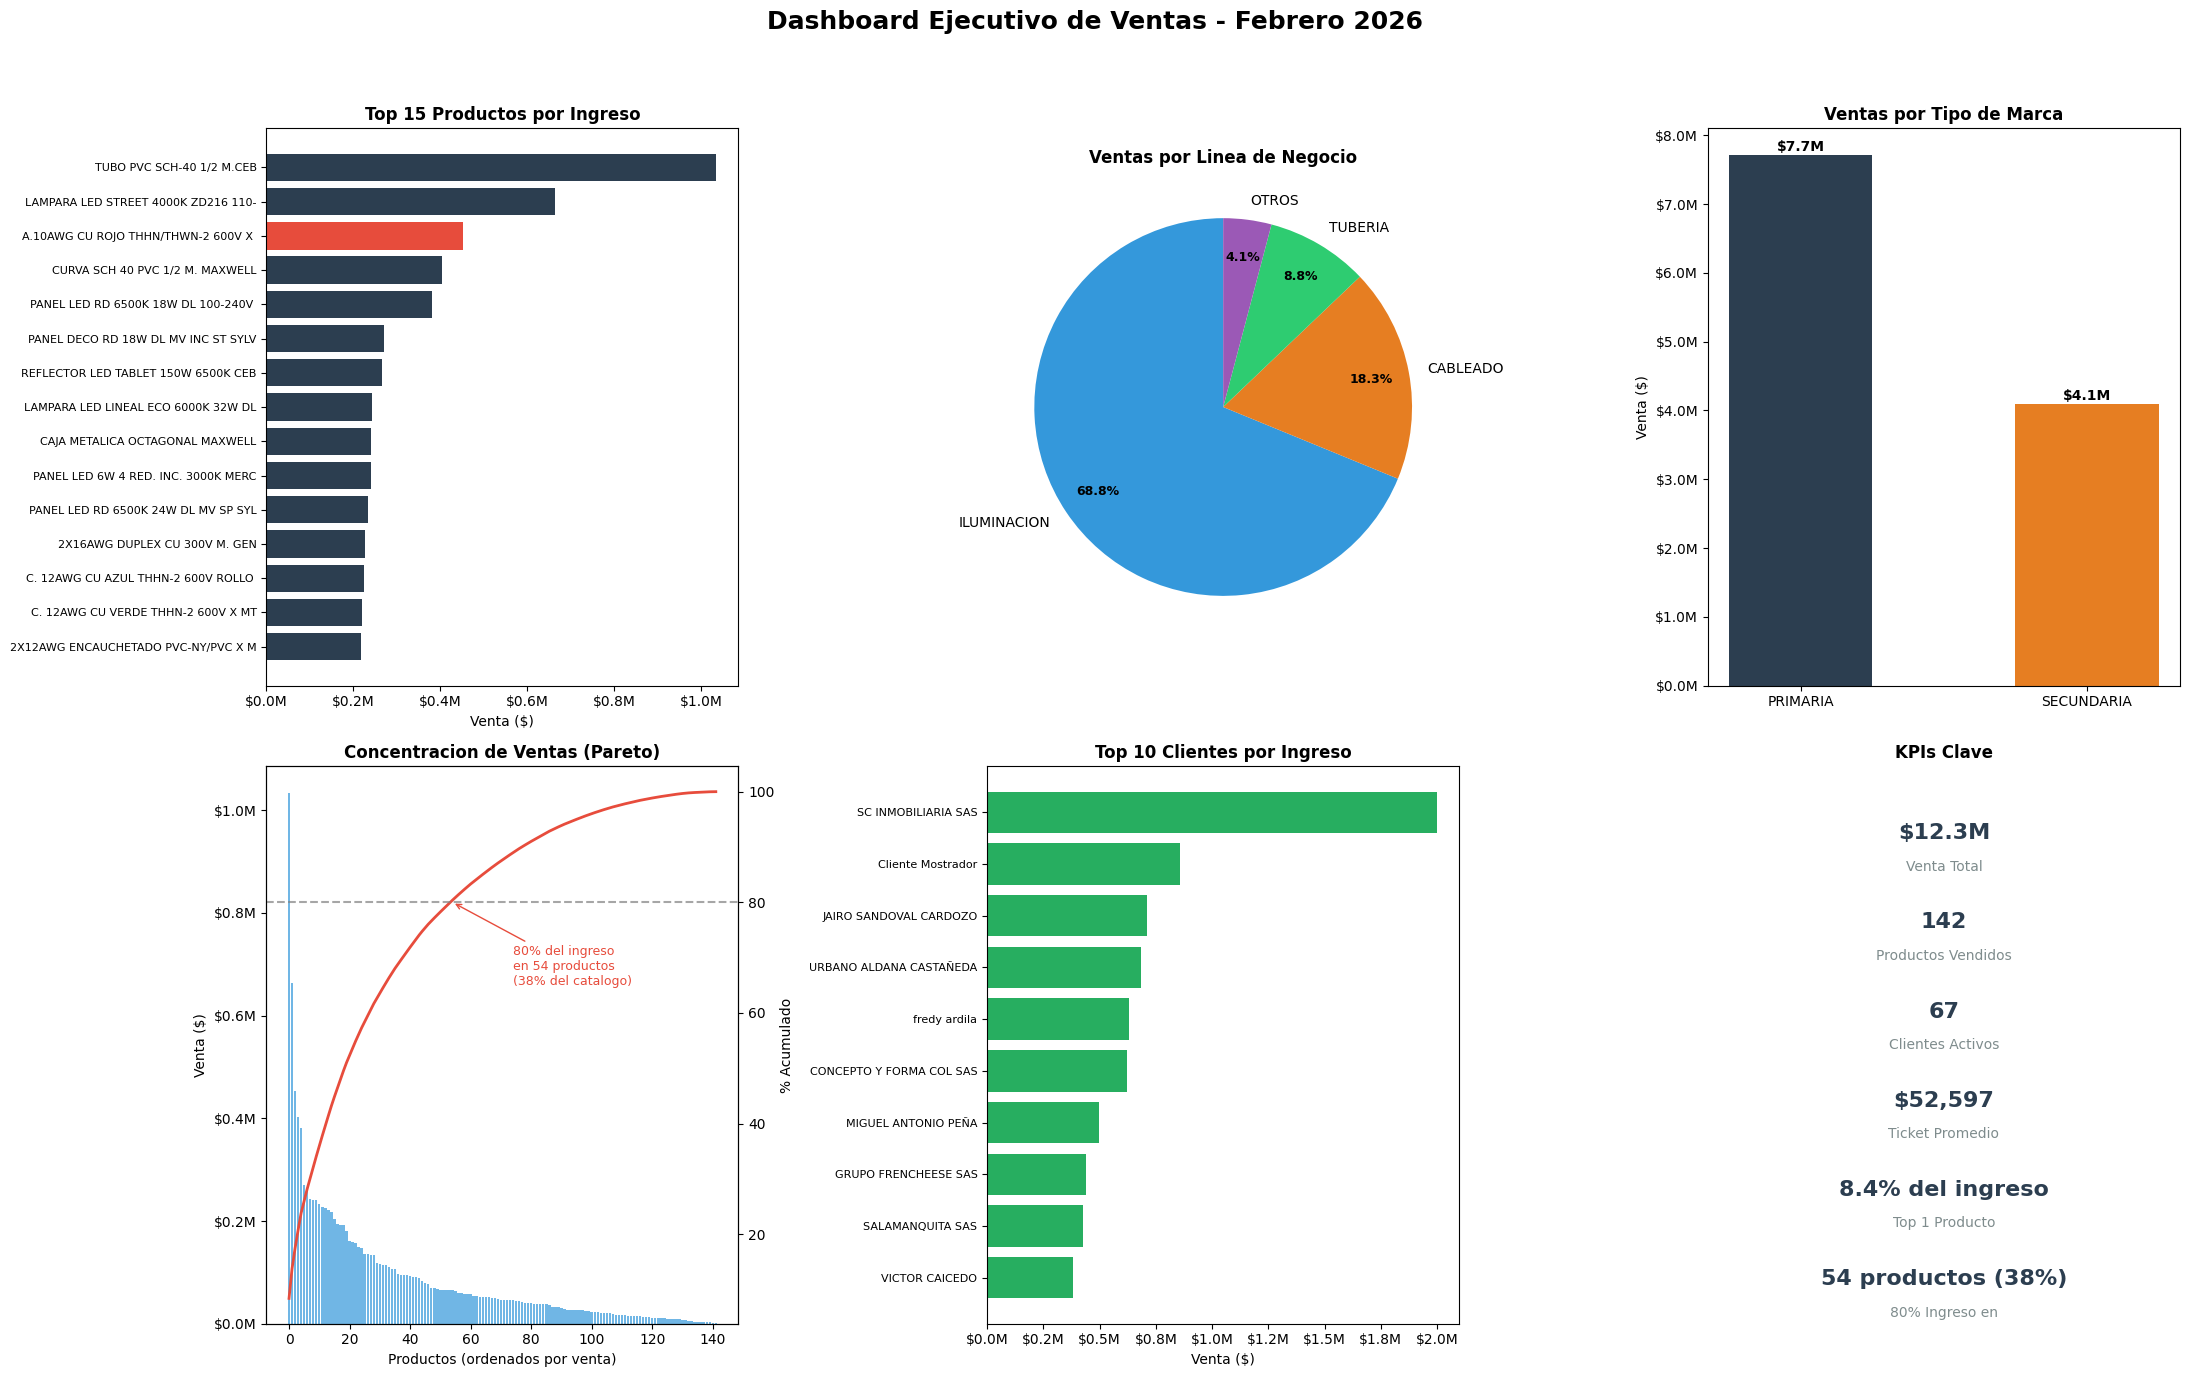

In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Dashboard Ejecutivo de Ventas - Febrero 2026', fontsize=18, fontweight='bold', y=0.98)
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# --- 1. Top 15 productos por ingreso ---
ax1 = axes[0, 0]
top15 = ventas_por_producto.head(15).copy()
top15['label'] = top15['Descripción'].str[:35]
colors1 = ['#e74c3c' if x == 'DESCONOCIDO' else '#2c3e50' for x in top15['Código producto']]
ax1.barh(range(len(top15)), top15['Venta_total'], color=colors1)
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(top15['label'], fontsize=8)
ax1.invert_yaxis()
ax1.set_xlabel('Venta ($)')
ax1.set_title('Top 15 Productos por Ingreso', fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# --- 2. Ventas por linea de negocio ---
ax2 = axes[0, 1]
por_linea = ventas_por_producto.groupby('Línea')['Venta_total'].sum().sort_values(ascending=False)
por_linea = por_linea[por_linea.index.notna()]
colors2 = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#95a5a6']
wedges, texts, autotexts = ax2.pie(
    por_linea, labels=por_linea.index, autopct='%1.1f%%',
    colors=colors2[:len(por_linea)], startangle=90, pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
ax2.set_title('Ventas por Linea de Negocio', fontweight='bold')

# --- 3. Marca primaria vs secundaria ---
ax3 = axes[0, 2]
por_marca = ventas_por_producto.groupby('Marca')['Venta_total'].sum().sort_values(ascending=False)
por_marca = por_marca[por_marca.index.notna()]
colors3 = ['#2c3e50', '#e67e22']
bars3 = ax3.bar(por_marca.index, por_marca.values, color=colors3[:len(por_marca)], width=0.5)
for bar, val in zip(bars3, por_marca.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
             f'${val/1e6:.1f}M', ha='center', fontweight='bold', fontsize=10)
ax3.set_title('Ventas por Tipo de Marca', fontweight='bold')
ax3.set_ylabel('Venta ($)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# --- 4. Pareto: concentracion de ventas ---
ax4 = axes[1, 0]
vpp_sorted = ventas_por_producto.sort_values('Venta_total', ascending=False).reset_index(drop=True)
cum_pct = vpp_sorted['Venta_total'].cumsum() / vpp_sorted['Venta_total'].sum() * 100
ax4.bar(range(len(vpp_sorted)), vpp_sorted['Venta_total'], color='#3498db', alpha=0.7)
ax4_twin = ax4.twinx()
ax4_twin.plot(range(len(vpp_sorted)), cum_pct, color='#e74c3c', linewidth=2)
ax4_twin.axhline(y=80, color='gray', linestyle='--', alpha=0.7)
n80 = int((cum_pct <= 80).sum())
ax4_twin.annotate(f'80% del ingreso\nen {n80} productos\n({n80/len(vpp_sorted)*100:.0f}% del catalogo)',
                  xy=(n80, 80), fontsize=9, color='#e74c3c',
                  xytext=(n80 + 20, 65), arrowprops=dict(arrowstyle='->', color='#e74c3c'))
ax4.set_xlabel('Productos (ordenados por venta)')
ax4.set_ylabel('Venta ($)')
ax4_twin.set_ylabel('% Acumulado')
ax4.set_title('Concentracion de Ventas (Pareto)', fontweight='bold')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# --- 5. Top 10 clientes ---
ax5 = axes[1, 1]
ventas_cliente = ventas.groupby('Nombre tercero')['Crédito'].sum().sort_values(ascending=False).head(10)
ventas_cliente_labels = [n[:30] for n in ventas_cliente.index]
ax5.barh(range(len(ventas_cliente)), ventas_cliente.values, color='#27ae60')
ax5.set_yticks(range(len(ventas_cliente)))
ax5.set_yticklabels(ventas_cliente_labels, fontsize=8)
ax5.invert_yaxis()
ax5.set_xlabel('Venta ($)')
ax5.set_title('Top 10 Clientes por Ingreso', fontweight='bold')
ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# --- 6. KPIs resumen ---
ax6 = axes[1, 2]
ax6.axis('off')
total_ventas = ventas_por_producto['Venta_total'].sum()
n_productos = len(ventas_por_producto)
n_clientes = ventas['Nombre tercero'].nunique()
ticket_promedio = ventas['Crédito'].mean()
top1_pct = ventas_por_producto.iloc[0]['Venta_total'] / total_ventas * 100

kpis = [
    ('Venta Total', f'${total_ventas/1e6:.1f}M'),
    ('Productos Vendidos', f'{n_productos}'),
    ('Clientes Activos', f'{n_clientes}'),
    ('Ticket Promedio', f'${ticket_promedio:,.0f}'),
    ('Top 1 Producto', f'{top1_pct:.1f}% del ingreso'),
    ('80% Ingreso en', f'{n80} productos ({n80/n_productos*100:.0f}%)'),
]

for i, (label, value) in enumerate(kpis):
    y = 0.88 - i * 0.16
    ax6.text(0.5, y, value, transform=ax6.transAxes, fontsize=16,
             fontweight='bold', ha='center', va='center', color='#2c3e50')
    ax6.text(0.5, y - 0.06, label, transform=ax6.transAxes, fontsize=10,
             ha='center', va='center', color='#7f8c8d')

ax6.set_title('KPIs Clave', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()